In [ ]:
import numpy as np
import pandas as pd
import re

import matplotlib.pyplot as plt

#draw images in vector format instead of pixel format making them crisper, and easier to import images
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import requests
import string

#https://pypi.org/project/tiktoken/
!pip install tiktoken
import tiktoken

!pip install anthropic

#Tokenization basics

In [ ]:
# the text
text = [ "It is not the critic who counts not the man who points out how the strong man stumbles or where the doer of deeds could have done better",
        "The credit belongs to the man who is actually in the arena, whose face is marred by dust and sweat and blood who strives valiantly",
         "who errs who comes short again and again because there is no effort without error or shortcoming but who does actually strive to do the deeds"
 ]

allwords = re.split(r"\s"," ".join(text).lower())
vocab = sorted(set(allwords))

# encoder and decoder dictionaries
word2idx = {word:i for i,word in enumerate(vocab)}
idx2word  = {i:word for i,word in enumerate(vocab)}

In [ ]:
#wrap the ecoder/decoder into functions
def encoder(txt):
  try:
    return word2idx[txt]
  except KeyError:
    raise ValueError(f"Word '{txt}' not found in vocabulary.")

def decoder(num):
  return idx2word[num]

#encoder and decoder are inverses of each other
decoder(encoder('sweat'))

'sweat'

In [ ]:
def encoder2(text):
  words = re.split(r"\s",text.lower())
  return [word2idx[i] for i in words]

def decoder2(idx_ls):
  w =  [idx2word[i] for i in idx_ls]
  return " ".join(w)


print(encoder2("sweat actually withouT"))
decoder2(encoder2("sweat actually withouT"))

[44, 0, 52]


'sweat actually without'

[29, 28, 33, 45, 14, 50, 12, 33, 45, 30, 50, 37, 36, 26, 45, 42, 30, 43, 35, 49, 45, 17, 34, 15, 11, 25, 19, 6, 45, 13, 5, 47, 45, 30, 50, 28, 0, 27, 45, 3, 51, 24, 28, 31, 9, 20, 2, 44, 2, 7, 50, 41, 48, 50, 23, 50, 10, 38, 1, 2, 1, 4, 46, 28, 32, 21, 52, 22, 35, 39, 8, 50, 18, 0, 40, 47, 16, 45, 15]


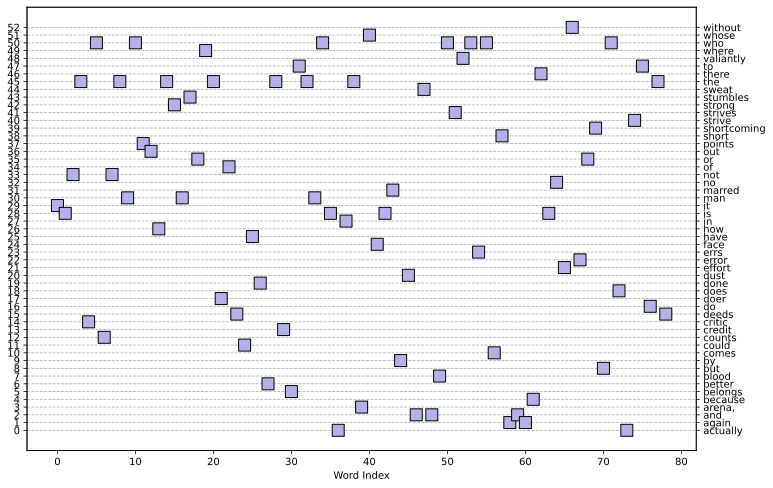

In [ ]:
#visualize tokens
text = [ "It is not the critic who counts not the man who points out how the strong man stumbles or where the doer of deeds could have done better",
        "The credit belongs to the man who is actually in the arena, whose face is marred by dust and sweat and blood who strives valiantly",
         "who errs who comes short again and again because there is no effort without error or shortcoming but who does actually strive to do the deeds"
 ]

altext = " ".join(text)
token = encoder2(altext)
print(token)

_,ax = plt.subplots(1,figsize = (12,8))

ax.plot(token,'ks',markersize = 12,markerfacecolor = [.7,.7,.9])
ax.set(xlabel="Word Index",yticks = range(len(vocab)) )
ax.grid(linestyle = "--",axis = 'y')

ax2 = ax.twinx() #twin axes
ax2.plot(token,alpha=0)
ax2.set(yticks = range(len(vocab)),yticklabels = vocab)
%matplotlib inline

In [ ]:
#exploring context around target tokens
x  = " ".join(text).lower()
y = re.split(" ",x)
y = np.array(y)

targetword = 'to'
print(np.argwhere(y == targetword))
print(y[29:33])
print(y[73:77])

[[31]
 [75]]
['credit' 'belongs' 'to' 'the']
['actually' 'strive' 'to' 'do']


In [ ]:
#one hot encoding (dummy encoding) to create a sparse matrix
# list of sentences
text = [ 'Today is a good good day' ]

# create a vocab of unique words
allwords = re.split(r'\s',' '.join(text).lower())
vocab = sorted(set(allwords))
print(f"length of text is {len(allwords)}; length of vocab is {len(vocab)}")

word2index = {word:i for i,word in enumerate(vocab)} #encoder
idx2word = { i:word for i,word in enumerate(vocab) } #decoder

word_matrix = np.zeros((len(allwords),len(vocab)),dtype = int)
word_matrix.shape

for i,word in enumerate(allwords):
  word_matrix[i,word2index[word]] = 1

print(text)
print(vocab)
word_matrix

length of text is 6; length of vocab is 5
['Today is a good good day']
['a', 'day', 'good', 'is', 'today']


array([[0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0],
       [1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 1, 0, 0, 0]])

#Text processing of an entire e-book

In [ ]:
#get raw text
book = requests.get("https://www.gutenberg.org/cache/epub/35/pg35.txt")

#extract just the text
text = book.text
print(type(text))
print(len(text))
text[:2000]

<class 'str'>
202461


'\ufeffThe Project Gutenberg eBook of The Time Machine\r\n    \r\nThis ebook is for the use of anyone anywhere in the United States and\r\nmost other parts of the world at no cost and with almost no restrictions\r\nwhatsoever. You may copy it, give it away or re-use it under the terms\r\nof the Project Gutenberg License included with this ebook or online\r\nat www.gutenberg.org. If you are not located in the United States,\r\nyou will have to check the laws of the country where you are located\r\nbefore using this eBook.\r\n\r\nTitle: The Time Machine\r\n\r\nAuthor: H. G. Wells\r\n\r\nRelease date: October 2, 2004 [eBook #35]\r\n                Most recently updated: April 19, 2025\r\n\r\nLanguage: English\r\n\r\n\r\n\r\n*** START OF THE PROJECT GUTENBERG EBOOK THE TIME MACHINE ***\r\n\r\n\r\n\r\n\r\nThe Time Machine\r\n\r\nAn Invention\r\n\r\nby H. G. Wells\r\n\r\n\r\nCONTENTS\r\n\r\n I Introduction\r\n II The Machine\r\n III The Time Traveller Returns\r\n IV Time Travelling\r\n V In 

In [ ]:
# character strings to replace with space
strings2replace = [ '\r\n\r\nâ\x80\x9c',
                   'â\x80\x9c',
                    'â\x80\x9d',
                    '\r\n','â\x80\x94',
                    'â\x80\x99',
                    'â\x80\x98',
                    '_',
                    ]

print('â\x80\x98'.encode('latin1').decode('utf8'))

#use regular expression to replace weird strings with space
for str2match in strings2replace:
  regexp = re.compile(r'%s'%str2match)
  text = regexp.sub(' ',text)

#remove non-ASCII characters
text = re.sub(r'[^\x00-\x7F]+',' ',text)

#replace digits with empty strings
text = re.sub('\d+','',text)

#lower case
text = text.lower()

text[:2000]

‘


<>:22: SyntaxWarning: invalid escape sequence '\d'
<>:22: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3699755852.py:22: SyntaxWarning: invalid escape sequence '\d'
  text = re.sub('\d+','',text)


' the project gutenberg ebook of the time machine      this ebook is for the use of anyone anywhere in the united states and most other parts of the world at no cost and with almost no restrictions whatsoever. you may copy it, give it away or re-use it under the terms of the project gutenberg license included with this ebook or online at www.gutenberg.org. if you are not located in the united states, you will have to check the laws of the country where you are located before using this ebook.  title: the time machine  author: h. g. wells  release date: october ,  [ebook #]                 most recently updated: april ,   language: english    *** start of the project gutenberg ebook the time machine ***     the time machine  an invention  by h. g. wells   contents   i introduction  ii the machine  iii the time traveller returns  iv time travelling  v in the golden age  vi the sunset of mankind  vii a sudden shock  viii explanation  ix the morlocks  x when night came  xi the palace of gr

In [ ]:
#text segmentation into words

#split by punctuation
print(string.punctuation)
puncts4re = f'[{string.punctuation}\s]+'

words = re.split(puncts4re,text)
words = [item.strip() for item in words if item.strip()]

#remove single character words
words = [item for item in words if len(item)>1]

words[:10]

vocab = sorted(set(words))
print("length of vocab ",len(vocab))

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
length of vocab  4917


<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-156636026.py:5: SyntaxWarning: invalid escape sequence '\s'
  puncts4re = f'[{string.punctuation}\s]+'


In [ ]:
word2idx = {word:i for i,word in enumerate(vocab)}
idx2word = {i:word for i,word in enumerate(vocab)}

for i in list(word2idx.items())[0:5]:
  print(i)

('abandon', 0)
('abandoned', 1)
('abide', 2)
('able', 3)
('abnormally', 4)


In [ ]:
def encoder(words,encode_dict):
  idxs = np.zeros((len(words)),dtype = int)

  for i,w in enumerate(words):
    idxs[i] = encode_dict[w]

  return idxs

def decoder(idxs,decode_dict):
  return ' '.join([decode_dict[i] for i in idxs])

#test
print(encoder(["abandon","abandoned","abnormally","to"],word2idx))
print(decoder([   0,    1,    4, 4416],idx2word))

[   0    1    4 4416]
abandon abandoned abnormally to


In [ ]:
print(encoder(["of","how","abnormally","tell"],word2idx))
print(decoder([   0,    1,    4, 4416],idx2word))

[2930 2112    4 4307]
abandon abandoned abnormally to


In [ ]:
randomTokens = np.random.choice(list(word2idx.values()),10) #alternatively np.random.randint(0,10,3)
print(randomTokens)
decoder(randomTokens,idx2word)

[2641  943 1538 4643 1387 1368 3434 2958 1870 2210]


'match culture family vast enormously encamp really operation go income'

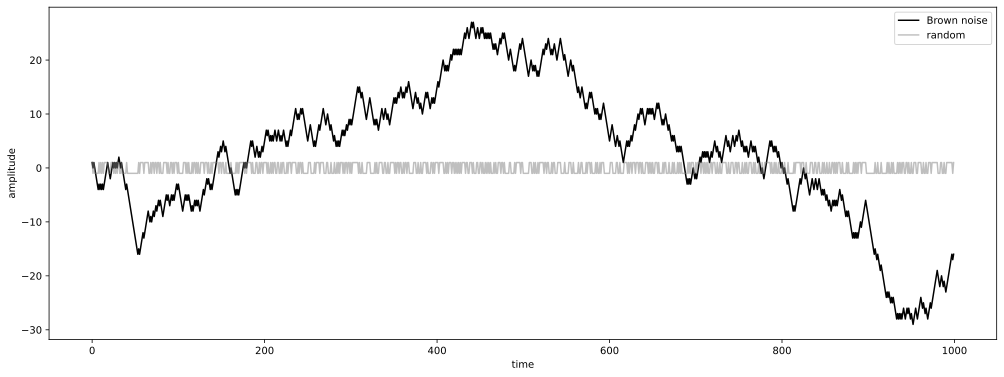

In [ ]:
x = np.random.choice([-1,1],1000)
#print(x)
y = np.cumsum(x)
#print(y)
plt.figure(figsize = (17,6))
plt.plot(y,'k',label = 'Brown noise')
plt.plot( x, color = 'grey',label = 'random',alpha = 0.5)
plt.xlabel("time")
plt.ylabel("amplitude")
plt.legend()

Text(0.5, 1.0, 'vocab distribution')

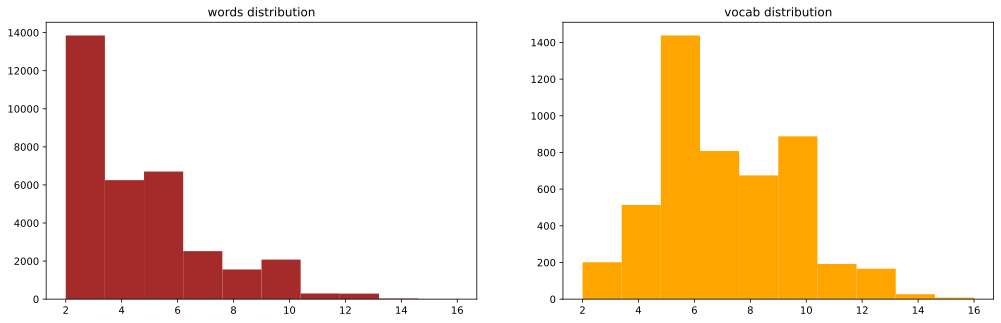

In [ ]:
#length of words and their frequencies. Results indicate that LLMs will need to be trained a lot more on smaller words rather than larger words
ls = []
for i in words:
  ls.append(len(i))

fig,ax = plt.subplots(1,2,figsize = (17,5))
ax[0].hist(ls,bins = 10,color = 'brown')
ax[0].set_title("words distribution")

ls = []
for i in vocab:
  ls.append(len(i))

ax[1].hist(ls,bins = 10,color = 'orange')
ax[1].set_title("vocab distribution")

In [ ]:
#dealing with unknown tokens
word2idx_new = word2idx.copy()
idx2word_new = idx2word.copy()

word2idx_new['<|unk|>'] = len(word2idx) + 1
idx2word_new[len(idx2word) + 1] = '<|unk|>'

def encoder_new(words,encode_dict):
  idxs = np.zeros((len(words)),dtype = int)

  for i,w in enumerate(words):
    if w in encode_dict:
      idxs[i] = encode_dict[w]
    else:
      idxs[i] = encode_dict['<|unk|>']

  return idxs

#test
print(encoder_new(["abandon","cc","abnormally","to"],word2idx_new)) #'<|unk|>' is 4918 and its used for 'cc'
print(decoder([   0,    1,    4, 4416],idx2word))

[   0 4918    4 4416]
abandon abandoned abnormally to


#Subwords / Basic Byte Pair Encoding (BPE) Algorithm

In [ ]:
#Token efficiency can be improved with tokens that represent longer character sequences
#what appears together is done emperically using existing large datasets found online

Byte-pair encoding algorithm
1. initialize vocabulary of only characters
2. loop through training data and count frequency of pairs of characters
3. most frequently pair is merged to create a new token
4. add token from step 3 into vocabulary
5. repeat from step 2

In [5]:
#GPT-4s tokenizr
tokenizer = tiktoken.get_encoding('cl100k_base')
type(tokenizer)

tiktoken.core.Encoding

In [6]:
dir(tokenizer)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_core_bpe',
 '_encode_bytes',
 '_encode_only_native_bpe',
 '_encode_single_piece',
 '_mergeable_ranks',
 '_pat_str',
 '_special_tokens',
 'decode',
 'decode_batch',
 'decode_bytes',
 'decode_bytes_batch',
 'decode_single_token_bytes',
 'decode_tokens_bytes',
 'decode_with_offsets',
 'encode',
 'encode_batch',
 'encode_ordinary',
 'encode_ordinary_batch',
 'encode_single_token',
 'encode_to_numpy',
 'encode_with_unstable',
 'eot_token',
 'is_special_token',
 'max_token_value',
 'n_vocab',
 'name',
 'special_tokens_set',
 'token_byte_values']

In [7]:
tokenizer.n_vocab

100277

In [9]:
tokenizer.decode([tokenizer.eot_token]) #end of text token

'<|endoftext|>'

In [13]:
tokenizer.decode([9991])

'cf'

In [22]:
txt = "Lets test these tokenizers out!"
tokens = tokenizer.encode(txt)
tokens

[94413, 1296, 1521, 4037, 12509, 704, 0]

#BERT

In [24]:
#can do missing word completions, hence this is more suited for tasks like sentimetn analysis
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
#title case (chatbots) vs lower case(reading pdfs) tokenizer use cases

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [26]:
dir(tokenizer)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__bool__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_bos_token',
 '_add_eos_token',
 '_add_tokens',
 '_auto_class',
 '_convert_encoding',
 '_convert_id_to_token',
 '_convert_token_to_id_with_added_voc',
 '_decode',
 '_encode_plus',
 '_eventual_warn_about_too_long_sequence',
 '_extra_special_tokens',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_target_context_manager',
 '_pad',
 '_pad_token_type_id',
 '_patch_mistral_regex',
 '_post_init',
 '_processor_class',
 '_save_pretrained',
 '_set_model_specific_s

In [36]:
#tokenizer.get_vocab()

In [32]:
all_tokens = list(tokenizer.get_vocab().keys())
all_tokens[1:10]

['რ',
 'infinite',
 'midday',
 'journalists',
 '‐',
 '##ias',
 'absorption',
 'hm',
 '##heater']

In [33]:
tokenizer.vocab_size

30522

In [35]:
print(tokenizer.convert_tokens_to_ids('test'))

3231

#Summary
- Token (segment of text); types : character token, subword token, word token, punctuation tokens etc.
- Token <-> Token id or Token index
- Further reading https://www.techradar.com/pro/what-is-a-token-in-ai-and-why-is-it-so-important
- https://tiktokenizer.f2api.com/
- text -> tokens -> embeddings -> LLMs

-  Embeddings : high dimensional,dynamic, vectorized, dense representations of tokens.
- Further reading : https://huggingface.co/spaces/hesamation/primer-llm-embedding?section=what_are_embeddings?
- Vocabulary (lexicon): unique set of tokens in a tokenizer
- Encoder : a function that maps text into token ids
- Decoder : a function that maps integers into text (inverse of encoder) i.e. decoder(encoder) = x

##How to select the correct tokenizer:                                                                               
To select the correct tokenizer, consider the following factors:
Model Compatibility: Ensure the tokenizer is compatible with the model you are using. Different models may require different tokenizers.

1. Task Requirements: Understand the specific tasks you need to perform with the tokenizer. Some tasks may require different types of tokenization, such as word or character tokenization.

2. Performance Metrics: Evaluate the tokenizer's performance metrics, such as text compression and downstream performance, to make an informed decision.

3. Tokenization Type: Choose between word, character, or sub-word tokenization based on the context and requirements of your application.

By considering these factors, you can select a tokenizer that best fits your needs and enhances the performance of your NLP tasks.